# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
*   Adding a penalty prevents the model from being too complex. The model may want as many coefficients as possible, but if the model gets penalized (more MSE) for adding an additional coefficient, only the most significant predictive variables will be included.

2. How does regularization provide a way of exploring the bias-variance trade-off?
*   Complex models have lower bias and higher variance. Regularization can help decrease the variance of the model, leading to more reliable predictions.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
*   LASSO can more clearly show which variables are worth keeping in the model, as it drops less significant ones, but Ridge opts to smooth everything out instead. Ridge does not completely remove coefficients, and is better at prediction compared to LASSO.

4. How do we typically scale variables for use in regularized regression? Why?
*   We use the z-score. Units for the predictor variables can vary, and we don't want to mix absurdly high or low values together to feed into our model. Z-scores normalize everything.

5. How is the penalty $\alpha$ typically selected?
*   Through k-fold cross validation. We pick the alpha with the least median MSE.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
*    No, the cross validation is trained on the different alphas/penalties. The penalty terms aren't included in the MSE, so that the folds are assessed by how well they predict overall at certain alpha values.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
# importing everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [2]:
! git clone https://github.com/AngelikaBaloy/undergrad_ml_assignments/

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 221 (delta 2), reused 1 (delta 1), pack-reused 216 (from 2)
Receiving objects: 100% (221/221), 18.46 MiB | 856.00 KiB/s, done.
Resolving deltas: 100% (92/92), done.


In [8]:
# 1. loading data, age & mileage_run
df_cars = pd.read_csv('./undergrad_ml_assignments/data/cars_hw.csv')
df_cars['Age']= 2026 - df_cars['Make_Year']


In [9]:
# polynomial expansion
cars_X = df_cars[['Mileage_Run','Age']]

expander = PolynomialFeatures(degree=3, include_bias=False) # third degree expansion
X_poly = expander.fit_transform(cars_X)
poly_names = expander.get_feature_names_out()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [13]:
# 2. linear regression
y = df_cars['Price']
model = LinearRegression()
model.fit(X_scaled, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'feature':poly_names, 'coefficient':model.coef_ })

# The sign for the interaction between mileage and age is positive

Model intercept: 741019.4672131148


,feature,coefficient
0,Mileage_Run,9.117748e+05
1,Age,-2.481722e+05
2,Mileage_Run^2,-2.072926e+05
3,Mileage_Run Age,-1.671212e+06
4,Age^2,3.505507e+05
5,Mileage_Run^3,-6.514490e+04
6,Mileage_Run^2 Age,3.388195e+05
7,Mileage_Run Age^2,7.167816e+05
8,Age^3,-2.100379e+05


In [20]:
X_scaled

array([[ 0.12469203, -0.01309242, -0.13767332, ..., -0.23076715,
        -0.19558597, -0.27042227],
       [-0.87233418,  0.34185769, -0.79131562, ..., -0.71818608,
        -0.56489035,  0.04408937],
       [-0.49351672, -0.72299265, -0.60062321, ..., -0.64800377,
        -0.70091085, -0.71839826],
       ...,
       [ 0.46248973,  1.05175792,  0.19479598, ...,  0.32073381,
         0.73673979,  0.88897673],
       [-0.54294553, -1.07794277, -0.62951357, ..., -0.69364241,
        -0.80062127, -0.86578933],
       [-0.01621083, -0.36804254, -0.25974731, ..., -0.38445401,
        -0.42380175, -0.52226369]])

In [43]:
# 3. lasso, kfcv w 20 folds
alpha_grid = np.logspace(1, 3, 20)
lasso_cv = LassoCV(cv=20, alphas=alpha_grid, random_state=100, max_iter=100000)
lasso_cv.fit(X_scaled, y)

alpha_star = lasso_cv.alpha_
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)
index_star = np.argmin(mean_mse_path)

coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

coefs_star = coefs[index_star]
selected_idx = np.nonzero(coefs_star)[0]
selected_features= poly_names[selected_idx].tolist()

lasso_star = Lasso(alpha=alpha_star, max_iter=100000).fit(X_scaled, y)
y_hat_lasso = lasso_star.predict(X_scaled)

print(f'Optimal alpha: {alpha_star}')
print(f'Selected features: {len(selected_features)}')
print(f'Discarded features: {X_scaled.shape[1] - len(selected_features)}')
selected_features

Optimal alpha: 88.58667904100822
Selected features: 8
Discarded features: 1


['Mileage_Run',
 'Age',
 'Mileage_Run^2',
 'Mileage_Run Age',
 'Mileage_Run^3',
 'Mileage_Run^2 Age',
 'Mileage_Run Age^2',
 'Age^3']

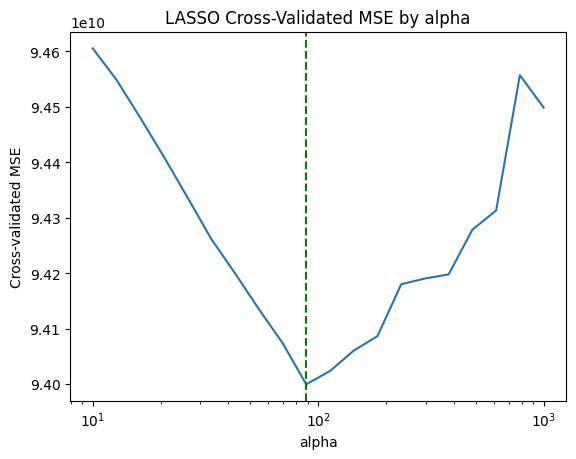

In [44]:
# 4. plot cv MSE by alpha
sns.lineplot(x=lasso_cv.alphas_, y=mean_mse_path)
plt.axvline(alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('LASSO Cross-Validated MSE by alpha')
plt.show()

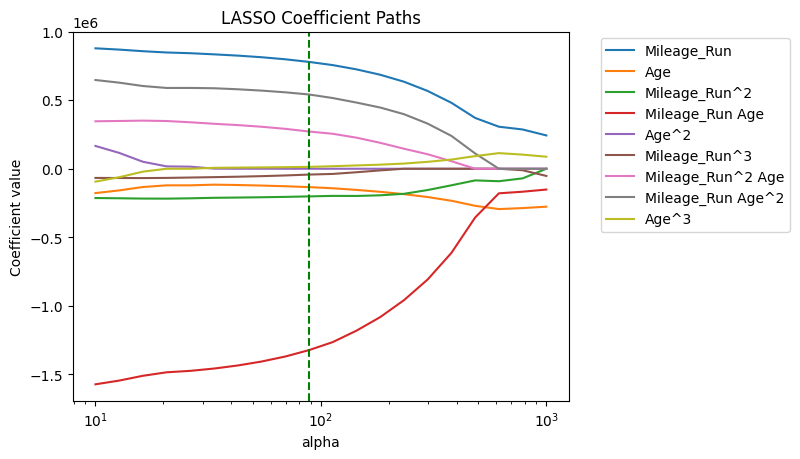

In [46]:
# 5. plot coefficient paths by alpha
coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(lasso_cv.alphas_, coefs[:,i], label=poly_names[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [ ]:
# 6.
# Only one feature (out of 9) gets set to 0.
# These are the selected features: 'Mileage_Run', 'Age', 'Mileage_Run^2','Mileage_Run Age',
#                                  'Mileage_Run^3', 'Mileage_Run^2 Age', 'Mileage_Run Age^2', 'Age^3'
# So Age^2 is dropped.


In [54]:
# 7. compare linear regressions and optimally regularized coefficients
reg_coefs = pd.DataFrame({'feature':poly_names, 'coefficient':model.coef_ })
reg_coefs

# the coefficients change in magnitude to various degrees, with some remaining
# relatively the same (small differences) with small decreases. All signs are
# the same. Mileage_Run^2 and ^3 get slightly more negative.
# Mileage_Run^2 Age gets slightly more positive.

,feature,coefficient
0,Mileage_Run,8.781495e+05
1,Age,-1.773732e+05
2,Mileage_Run^2,-2.134864e+05
3,Mileage_Run Age,-1.571865e+06
4,Age^2,1.662694e+05
5,Mileage_Run^3,-6.688081e+04
6,Mileage_Run^2 Age,3.462135e+05
7,Mileage_Run Age^2,6.470308e+05
8,Age^3,-9.379344e+04


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?